# Supply Chain Contagion — Phase 3
## Advanced Models

Phase 2 established:
- ARIMA and Holt-Winters forecast stable ports well (Singapore MAPE 7.2%)
  but struggle with volatile ports (Nagoya MAPE 30.9%)
- Both models produce flat forecasts — cannot capture external event-driven volatility
- Cross-correlation confirmed regional contagion:
  Japanese cluster (Yokohama, Nagoya, Kobe, Chiba, Mizushima, Sakai-Semboku)
  and Ningbo → Shanghai at lag 1

Phase 3 models are chosen based on these findings:
1. VAR — formally models confirmed lead-lag relationships between port pairs
2. Prophet — individual port forecasting with external event regressors
3. XGBoost — lag features from cross-correlation as inputs, interpretable cascade model

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
from itertools import product
warnings.filterwarnings('ignore')

# Load processed data
port_ts = pd.read_csv(
    '../outputs/processed/port_activity_top20.csv',
    index_col='date', parse_dates=True
)
pde_df = pd.read_csv(
    '../outputs/processed/pde_flags.csv',
    index_col='date', parse_dates=True
)
arima_df = pd.read_csv('../outputs/processed/arima_results.csv')
significant = pd.read_csv('../outputs/processed/significant_pairs.csv')

top_ports  = port_ts.columns.tolist()
split_date = port_ts.index.max() - pd.DateOffset(months=3)

print(f"Data loaded. Split date: {split_date.date()}")
print(f"Significant pairs loaded: {len(significant)}")

Data loaded. Split date: 2025-11-06
Significant pairs loaded: 172


## Step 1: VAR — Modelling Confirmed Port Clusters

Phase 2 cross-correlation found that contagion is regional.
The strongest cluster: Yokohama, Nagoya, Kobe, Chiba, Mizushima, Sakai-Semboku.
All at lag 1 — disruption spreads to neighbouring ports the next day.

VAR (Vector Autoregression) models multiple time series simultaneously.
Unlike ARIMA which only looks at one port's own history,
VAR says: "Nagoya's forecast today depends on both Nagoya's past
AND Yokohama's past."

We build VAR for two confirmed clusters:
1. Japanese cluster — 6 ports
2. Ningbo-Shanghai pair

I used raw portcalls series — not PDE binary series —
because VAR forecasts continuous values.

In [7]:
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import grangercausalitytests

# Confirmed clusters from cross-correlation
clusters = {
    'Japanese Cluster': [
        'Yokohama', 'Nagoya', 'Kobe',
        'Chiba', 'Mizushima', 'Sakai-Semboku'
    ],
    'China Coast': ['Ningbo', 'Shanghai (Pudong)']
}

def safe_mape(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

var_results = []

for cluster_name, ports in clusters.items():
    print(f"Cluster: {cluster_name}")

    cluster_data = port_ts[ports].dropna()
    train = cluster_data[cluster_data.index <= split_date]
    test  = cluster_data[cluster_data.index > split_date]

    # Fit VAR — AIC selects lag order
    model     = VAR(train)
    result    = model.fit(maxlags=14, ic='aic')
    lag_order = result.k_ar
    print(f"VAR lag order selected: {lag_order}")

    # Forecast
    forecast    = result.forecast(train.values[-lag_order:], steps=len(test))
    forecast_df = pd.DataFrame(forecast, index=test.index, columns=ports)

    # Metrics for each port in cluster
    for port in ports:
        mae  = mean_absolute_error(test[port], forecast_df[port])
        rmse = np.sqrt(mean_squared_error(test[port], forecast_df[port]))
        mape = safe_mape(test[port], forecast_df[port])

        # Get Phase 2 ARIMA baseline for comparison
        arima_mape = arima_df[arima_df['port']==port]['MAPE'].values[0]
        improvement = arima_mape - mape

        var_results.append({
            'cluster' : cluster_name,
            'port'    : port,
            'VAR_RMSE': round(rmse, 2),
            'VAR_MAPE': round(mape, 2),
            'ARIMA_MAPE': arima_mape,
            'Improvement': round(improvement, 2)
        })
        print(f"  {port:<25} VAR MAPE={mape:.1f}%  "
              f"ARIMA MAPE={arima_mape:.1f}%  "
              f"Improvement={improvement:+.1f}%")

var_df = pd.DataFrame(var_results)

Cluster: Japanese Cluster
VAR lag order selected: 14
  Yokohama                  VAR MAPE=27.8%  ARIMA MAPE=28.1%  Improvement=+0.3%
  Nagoya                    VAR MAPE=32.9%  ARIMA MAPE=30.9%  Improvement=-2.0%
  Kobe                      VAR MAPE=27.3%  ARIMA MAPE=27.3%  Improvement=+0.0%
  Chiba                     VAR MAPE=28.7%  ARIMA MAPE=29.9%  Improvement=+1.1%
  Mizushima                 VAR MAPE=29.2%  ARIMA MAPE=28.2%  Improvement=-1.0%
  Sakai-Semboku             VAR MAPE=31.8%  ARIMA MAPE=30.0%  Improvement=-1.8%
Cluster: China Coast
VAR lag order selected: 14
  Ningbo                    VAR MAPE=15.8%  ARIMA MAPE=15.2%  Improvement=-0.6%
  Shanghai (Pudong)         VAR MAPE=12.6%  ARIMA MAPE=13.8%  Improvement=+1.2%


In [8]:
# Granger causality test for strongest pair
# Does Yokohama Granger-cause Nagoya?
print("Granger Causality Test — Yokohama → Nagoya\n")

pair_data = port_ts[['Nagoya', 'Yokohama']].dropna()
gc = grangercausalitytests(pair_data, maxlag=3, verbose=False)

for lag, res in gc.items():
    pval = res[0]['ssr_ftest'][1]
    sig  = 'significant' if pval < 0.05 else 'not significant'
    print(f"Lag {lag}: p-value={pval:.4f} — {sig}")

Granger Causality Test — Yokohama → Nagoya

Lag 1: p-value=0.0000 — significant
Lag 2: p-value=0.0000 — significant
Lag 3: p-value=0.0000 — significant


### What is Granger Causality?

Granger causality asks a specific question:
"Does knowing Yokohama's past improve our forecast of Nagoya
beyond what Nagoya's own past already tells us?"

If yes — Yokohama Granger-causes Nagoya.
This is stronger evidence than correlation alone.
Correlation just says they move together.
Granger causality says one actually helps predict the other.

p < 0.05 = Yokohama's history significantly improves Nagoya's forecast.
This confirms the contagion relationship is directional and real.

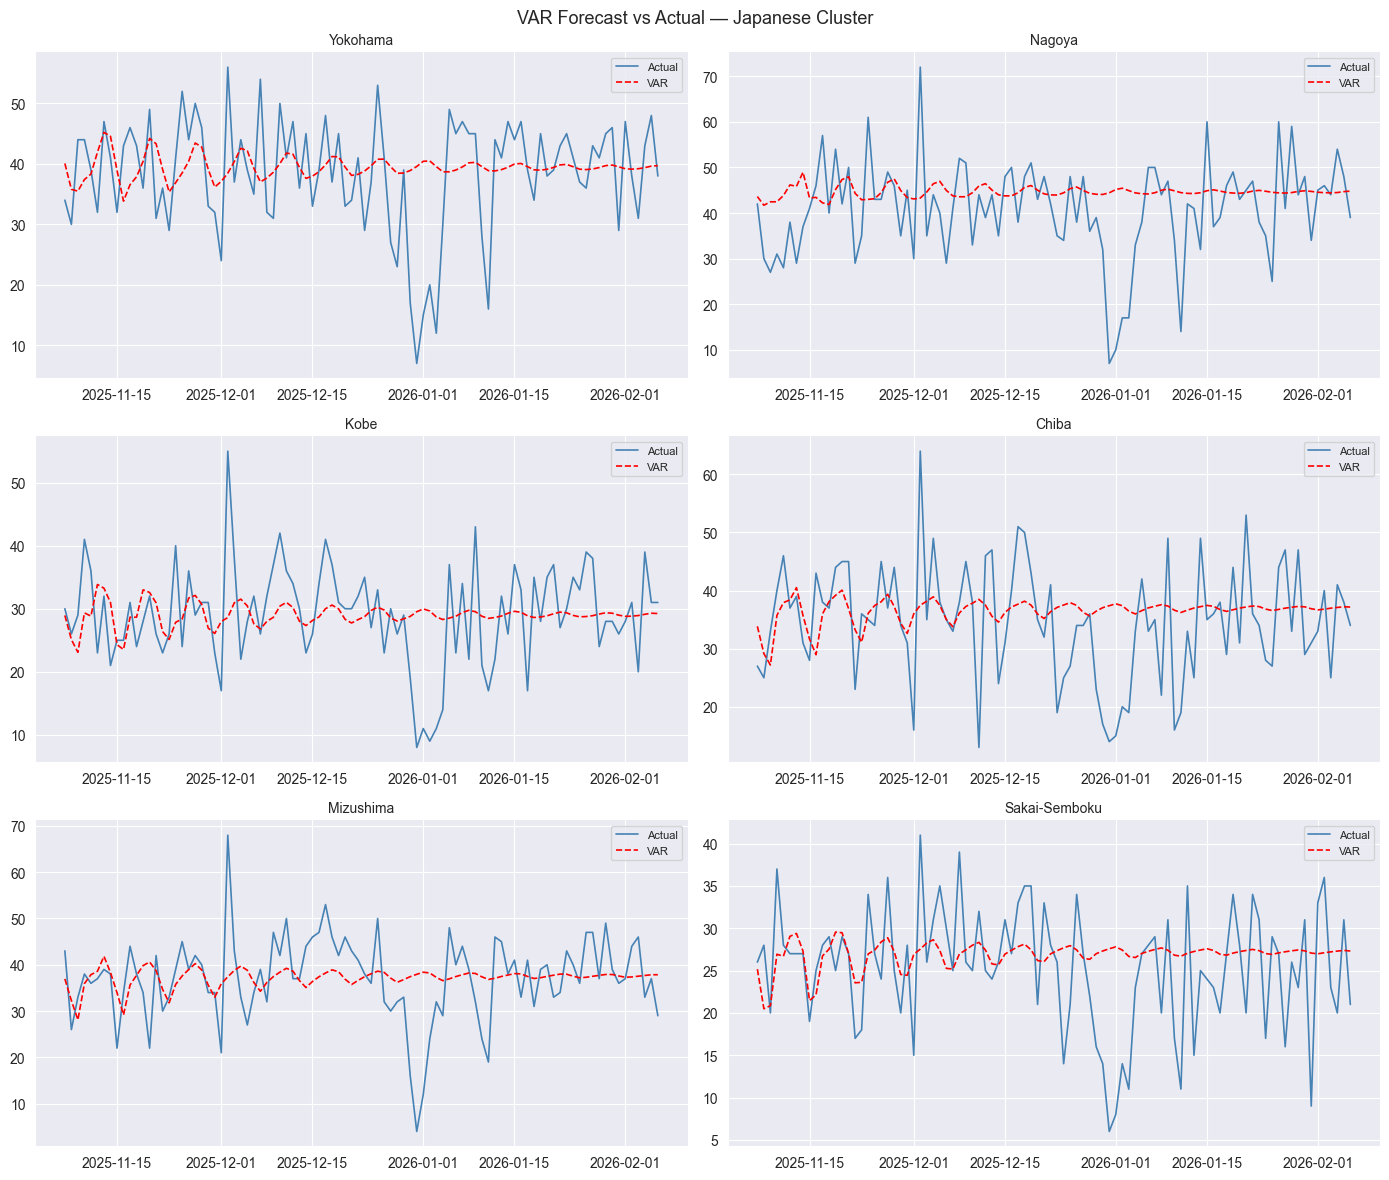

In [9]:
# Plot VAR forecast vs actual for Japanese cluster
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
fig.suptitle("VAR Forecast vs Actual — Japanese Cluster", fontsize=13)
axes = axes.flatten()

japanese_ports = clusters['Japanese Cluster']
cluster_data   = port_ts[japanese_ports].dropna()
train = cluster_data[cluster_data.index <= split_date]
test  = cluster_data[cluster_data.index > split_date]

result    = VAR(train).fit(maxlags=14, ic='aic')
forecast  = result.forecast(train.values[-result.k_ar:], steps=len(test))
forecast_df = pd.DataFrame(forecast, index=test.index, columns=japanese_ports)

for ax, port in zip(axes, japanese_ports):
    ax.plot(test.index, test[port].values,
            color='steelblue', linewidth=1.2, label='Actual')
    ax.plot(forecast_df.index, forecast_df[port].values,
            color='red', linewidth=1.2, linestyle='--', label='VAR')
    ax.set_title(port, fontsize=10)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/10_var_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 2: Prophet — Individual Port Forecasting with External Events

Phase 2 showed classical models produce flat forecasts because
they cannot incorporate external information.

Prophet addresses this directly:
- Handles trend changepoints automatically — COVID dip and recovery
- Accepts holidays and events as explicit inputs
- Multiple seasonality handling

We add three known disruption events as regressors:
- COVID-19 lockdowns (March 2020)
- Suez Canal blockage (March 2021)
- Red Sea Crisis (December 2023)

These are the events we annotated in Phase 1.
Prophet will learn how much each event affected vessel calls.

In [10]:
from prophet import Prophet

# Known disruption events as external regressors
events = pd.DataFrame({
    'ds': pd.to_datetime(['2020-03-15', '2021-03-23', '2023-12-01']),
    'event': [1, 1, 1]
})

def make_event_regressor(date_range, event_dates, window=30):
    """Mark days within 30 days of a known event as 1"""
    regressor = pd.Series(0, index=date_range)
    for ed in event_dates:
        mask = (date_range >= ed) & (date_range <= ed + pd.Timedelta(days=window))
        regressor[mask] = 1
    return regressor

prophet_results = []
prophet_models  = {}

for port in top_ports:
    series = port_ts[port].dropna()
    train  = series[series.index <= split_date]
    test   = series[series.index > split_date]

    # Prophet requires columns named 'ds' and 'y'
    train_df = pd.DataFrame({'ds': train.index, 'y': train.values})
    test_df  = pd.DataFrame({'ds': test.index})

    # Add event regressor
    event_dates = pd.to_datetime(['2020-03-15', '2021-03-23', '2023-12-01'])
    train_df['disruption'] = make_event_regressor(
        train.index, event_dates).values
    test_df['disruption']  = make_event_regressor(
        test.index, event_dates).values

    # Fit Prophet
    m = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05
    )
    m.add_regressor('disruption')
    m.fit(train_df)

    # Forecast
    forecast    = m.predict(test_df)
    predictions = pd.Series(forecast['yhat'].values, index=test.index)

    mae  = mean_absolute_error(test, predictions)
    rmse = np.sqrt(mean_squared_error(test, predictions))
    mape = np.mean(np.abs((test - predictions) / test.replace(0, np.nan))) * 100
    arima_mape = arima_df[arima_df['port']==port]['MAPE'].values[0]

    prophet_models[port]  = {'model': m, 'forecast': predictions}
    prophet_results.append({
        'port'        : port,
        'Prophet_RMSE': round(rmse, 2),
        'Prophet_MAPE': round(mape, 2),
        'ARIMA_MAPE'  : arima_mape,
        'Improvement' : round(arima_mape - mape, 2)
    })
    print(f"{port:<25} Prophet MAPE={mape:.1f}%  "
          f"ARIMA MAPE={arima_mape:.1f}%  "
          f"Improvement={arima_mape-mape:+.1f}%")

prophet_df = pd.DataFrame(prophet_results)

14:04:07 - cmdstanpy - INFO - Chain [1] start processing
14:04:07 - cmdstanpy - INFO - Chain [1] done processing
14:04:07 - cmdstanpy - INFO - Chain [1] start processing


Antwerp                   Prophet MAPE=17.6%  ARIMA MAPE=17.4%  Improvement=-0.2%


14:04:07 - cmdstanpy - INFO - Chain [1] done processing
14:04:07 - cmdstanpy - INFO - Chain [1] start processing


Busan                     Prophet MAPE=12.4%  ARIMA MAPE=13.1%  Improvement=+0.8%


14:04:07 - cmdstanpy - INFO - Chain [1] done processing
14:04:08 - cmdstanpy - INFO - Chain [1] start processing


...

Tianjin Xin Gang          Prophet MAPE=25.6%  ARIMA MAPE=25.1%  Improvement=-0.4%


14:04:13 - cmdstanpy - INFO - Chain [1] done processing
14:04:14 - cmdstanpy - INFO - Chain [1] start processing


Ulsan                     Prophet MAPE=29.1%  ARIMA MAPE=24.8%  Improvement=-4.3%


14:04:14 - cmdstanpy - INFO - Chain [1] done processing


Yokohama                  Prophet MAPE=24.9%  ARIMA MAPE=28.1%  Improvement=+3.2%


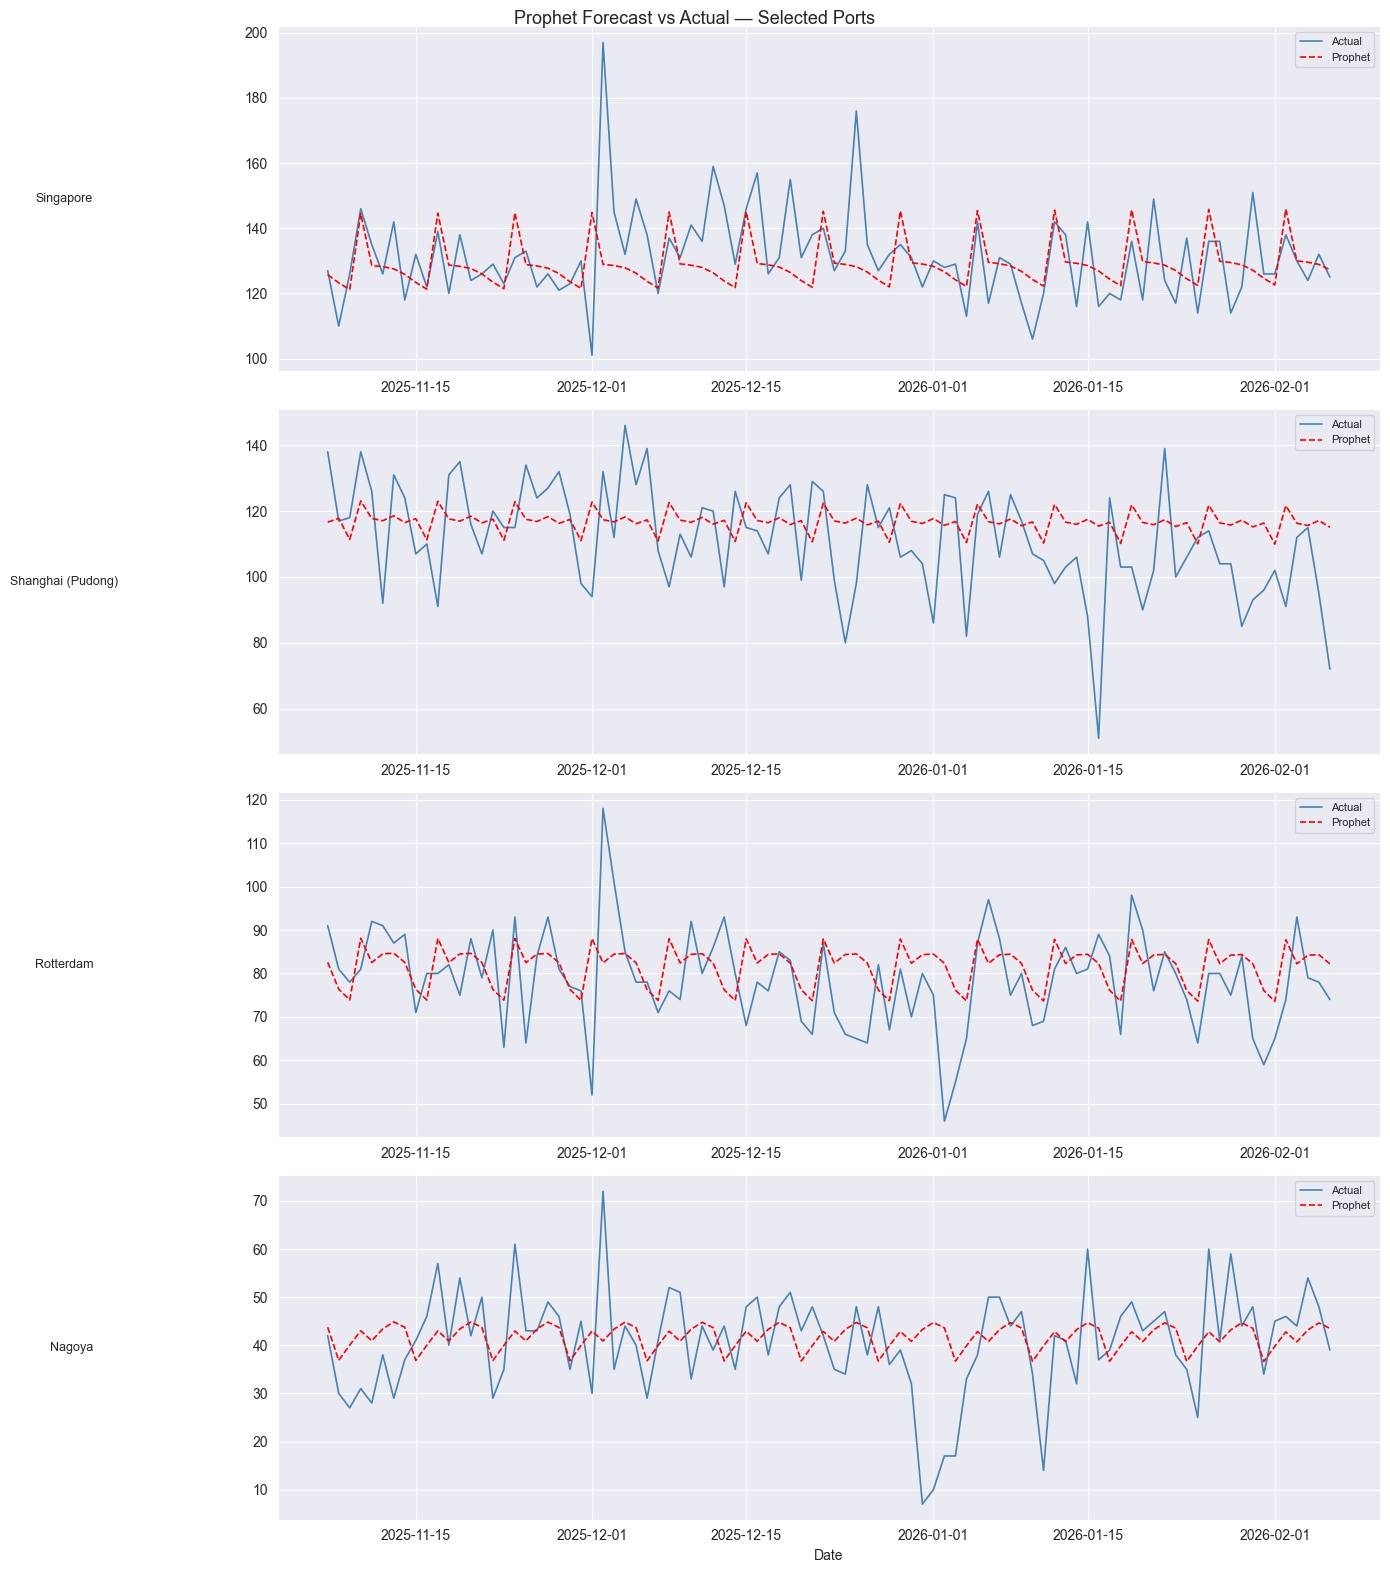

In [11]:
# Plot Prophet forecast for top 4 ports
plot_ports = ['Singapore', 'Shanghai (Pudong)', 'Rotterdam', 'Nagoya']

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle("Prophet Forecast vs Actual — Selected Ports", fontsize=13)

for ax, port in zip(axes, plot_ports):
    series = port_ts[port].dropna()
    test   = series[series.index > split_date]
    pred   = prophet_models[port]['forecast']

    ax.plot(test.index, test.values,
            color='steelblue', linewidth=1.2, label='Actual')
    ax.plot(pred.index, pred.values,
            color='red', linewidth=1.2, linestyle='--', label='Prophet')
    ax.set_ylabel(port, fontsize=9, rotation=0, labelpad=130, va='center')
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig('../outputs/figures/11_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3: XGBoost — Lag Features from Cross-Correlation

Phase 2 cross-correlation found that disruption spreads at lag 1.
XGBoost uses this finding directly — we engineer lag features
based on what cross-correlation told us.

For each port, the features are:
- Its own past 1, 2, 3, 7 days of vessel calls
- Its confirmed leading port's past 1, 2, 3 days of vessel calls

XGBoost then learns which of these lag features are most predictive.
Feature importance output tells us exactly which lags matter most.

This is the interpretable answer to the contagion question:
"Which port's disruption history best predicts this port's future?"

In [12]:
from xgboost import XGBRegressor

# Build lead-lag map from cross-correlation results
# For each port, find its strongest leading port
lead_map = {}
for port in top_ports:
    leaders = significant[significant['port_b'] == port].sort_values(
        'corr', ascending=False)
    if len(leaders) > 0:
        lead_map[port] = leaders.iloc[0]['port_a']
    else:
        lead_map[port] = None

print("Lead port map (Port → its strongest predictor):\n")
for port, leader in lead_map.items():
    print(f"  {port:<25} ← {leader if leader else 'None (independent)'}")

Lead port map (Port → its strongest predictor):

  Antwerp                   ← Chiba
  Busan                     ← Ningbo
  Chiba                     ← Nagoya
  Guangzhou (Nansha)        ← Hong Kong
  Gwangyang (Kwangyang)     ← Busan
  Hong Kong                 ← Kaohsiung
  Kaohsiung                 ← Ningbo
  Kobe                      ← Nagoya
  Mizushima                 ← Chiba
  Nagoya                    ← Yokohama
  Ningbo                    ← Qingdao
  Port Klang                ← Ningbo
  Qingdao                   ← Tianjin Xin Gang
  Rotterdam                 ← Yokohama
  Sakai-Semboku             ← Mizushima
  Shanghai (Pudong)         ← Ningbo
  Singapore                 ← Guangzhou (Nansha)
  Tianjin Xin Gang          ← Qingdao
  Ulsan                     ← Ningbo
  Yokohama                  ← Chiba


In [13]:
# ── Hyperparameter Tuning — Japanese Cluster Only ─────────────────────────
# Motivated by Phase 2: Japanese cluster has confirmed leader-lag signal.
# Tuning is restricted to this cluster — tuning independent ports would
# have no motivated basis since they have no leader features.
# Validation: last 30 days of training data held out.

from itertools import product

param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [3, 5]
}

VAL_DAYS = 30
tuning_results = {}

for port in clusters['Japanese Cluster']:
    series = port_ts[port].dropna()
    leader = lead_map[port]

    feat_df = pd.DataFrame(index=series.index)
    feat_df['y'] = series
    for lag in [1, 2, 3, 7]:
        feat_df[f'own_lag{lag}'] = series.shift(lag)
    if leader:
        leader_series = port_ts[leader]
        for lag in [1, 2, 3]:
            feat_df[f'leader_lag{lag}'] = leader_series.shift(lag)
    feat_df = feat_df.dropna()

    train_val = feat_df[feat_df.index <= split_date]
    X_tv = train_val.drop('y', axis=1)
    y_tv = train_val['y']

    X_tr  = X_tv.iloc[:-VAL_DAYS]
    y_tr  = y_tv.iloc[:-VAL_DAYS]
    X_val = X_tv.iloc[-VAL_DAYS:]
    y_val = y_tv.iloc[-VAL_DAYS:]

    best_rmse, best_params = np.inf, {}
    for n_est, lr, depth in product(
        param_grid['n_estimators'],
        param_grid['learning_rate'],
        param_grid['max_depth']
    ):
        m = XGBRegressor(n_estimators=n_est, learning_rate=lr,
                         max_depth=depth, random_state=42, verbosity=0)
        m.fit(X_tr, y_tr)
        rmse = np.sqrt(mean_squared_error(y_val, m.predict(X_val)))
        if rmse < best_rmse:
            best_rmse   = rmse
            best_params = {'n_estimators': n_est,
                           'learning_rate': lr,
                           'max_depth': depth}

    tuning_results[port] = best_params
    print(f"{port:<25} best={best_params}  val RMSE={best_rmse:.2f}")

print("\nTuning complete.")

Yokohama                  best={'n_estimators': 50, 'learning_rate': 0.05, 'max_depth': 3}  val RMSE=8.54
Nagoya                    best={'n_estimators': 100, 'learning_rate': 0.2, 'max_depth': 5}  val RMSE=9.50
Kobe                      best={'n_estimators': 100, 'learning_rate': 0.2, 'max_depth': 3}  val RMSE=5.23
Chiba                     best={'n_estimators': 50, 'learning_rate': 0.2, 'max_depth': 3}  val RMSE=8.36
Mizushima                 best={'n_estimators': 50, 'learning_rate': 0.1, 'max_depth': 3}  val RMSE=6.27
Sakai-Semboku             best={'n_estimators': 100, 'learning_rate': 0.2, 'max_depth': 3}  val RMSE=7.64

Tuning complete.


In [14]:
xgb_results = {}
xgb_models  = {}

for port in top_ports:
    series = port_ts[port].dropna()
    leader = lead_map[port]

    # Build feature dataframe
    feat_df = pd.DataFrame(index=series.index)
    feat_df['y'] = series

    # Own lags
    for lag in [1, 2, 3, 7]:
        feat_df[f'own_lag{lag}'] = series.shift(lag)

    # Leader port lags (if confirmed)
    if leader:
        leader_series = port_ts[leader]
        for lag in [1, 2, 3]:
            feat_df[f'leader_lag{lag}'] = leader_series.shift(lag)

    feat_df = feat_df.dropna()

    train_feat = feat_df[feat_df.index <= split_date]
    test_feat  = feat_df[feat_df.index > split_date]

    X_train = train_feat.drop('y', axis=1)
    y_train = train_feat['y']
    X_test  = test_feat.drop('y', axis=1)
    y_test  = test_feat['y']

    # model = XGBRegressor(n_estimators=100, learning_rate=0.1,
    #                      random_state=42, verbosity=0)

    params = tuning_results.get(port, {'n_estimators': 100,
                                    'learning_rate': 0.1,
                                    'max_depth': 3})
    model = XGBRegressor(**params, random_state=42, verbosity=0)
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae  = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mape = safe_mape(y_test, predictions)
    arima_mape = arima_df[arima_df['port']==port]['MAPE'].values[0]

    xgb_models[port] = {'model': model, 'predictions': predictions,
                        'test_index': y_test.index}
    xgb_results[port] = {
        'port'        : port,
        'XGB_RMSE'    : round(rmse, 2),
        'XGB_MAPE'    : round(mape, 2),
        'ARIMA_MAPE'  : arima_mape,
        'Improvement' : round(arima_mape - mape, 2)
    }
    print(f"{port:<25} XGB MAPE={mape:.1f}%  "
          f"ARIMA MAPE={arima_mape:.1f}%  "
          f"Improvement={arima_mape-mape:+.1f}%")

xgb_df = pd.DataFrame(xgb_results.values())

Antwerp                   XGB MAPE=19.2%  ARIMA MAPE=17.4%  Improvement=-1.9%
Busan                     XGB MAPE=14.4%  ARIMA MAPE=13.1%  Improvement=-1.3%
Chiba                     XGB MAPE=26.7%  ARIMA MAPE=29.9%  Improvement=+3.1%
Guangzhou (Nansha)        XGB MAPE=17.4%  ARIMA MAPE=17.4%  Improvement=-0.1%
Gwangyang (Kwangyang)     XGB MAPE=19.3%  ARIMA MAPE=17.8%  Improvement=-1.5%
Hong Kong                 XGB MAPE=12.4%  ARIMA MAPE=13.0%  Improvement=+0.7%
Kaohsiung                 XGB MAPE=28.8%  ARIMA MAPE=26.5%  Improvement=-2.3%
Kobe                      XGB MAPE=21.8%  ARIMA MAPE=27.3%  Improvement=+5.5%
Mizushima                 XGB MAPE=22.8%  ARIMA MAPE=28.2%  Improvement=+5.5%
Nagoya                    XGB MAPE=26.4%  ARIMA MAPE=30.9%  Improvement=+4.5%
Ningbo                    XGB MAPE=15.5%  ARIMA MAPE=15.2%  Improvement=-0.3%
Port Klang                XGB MAPE=15.1%  ARIMA MAPE=13.6%  Improvement=-1.5%
Qingdao                   XGB MAPE=16.0%  ARIMA MAPE=16.3%  Impr

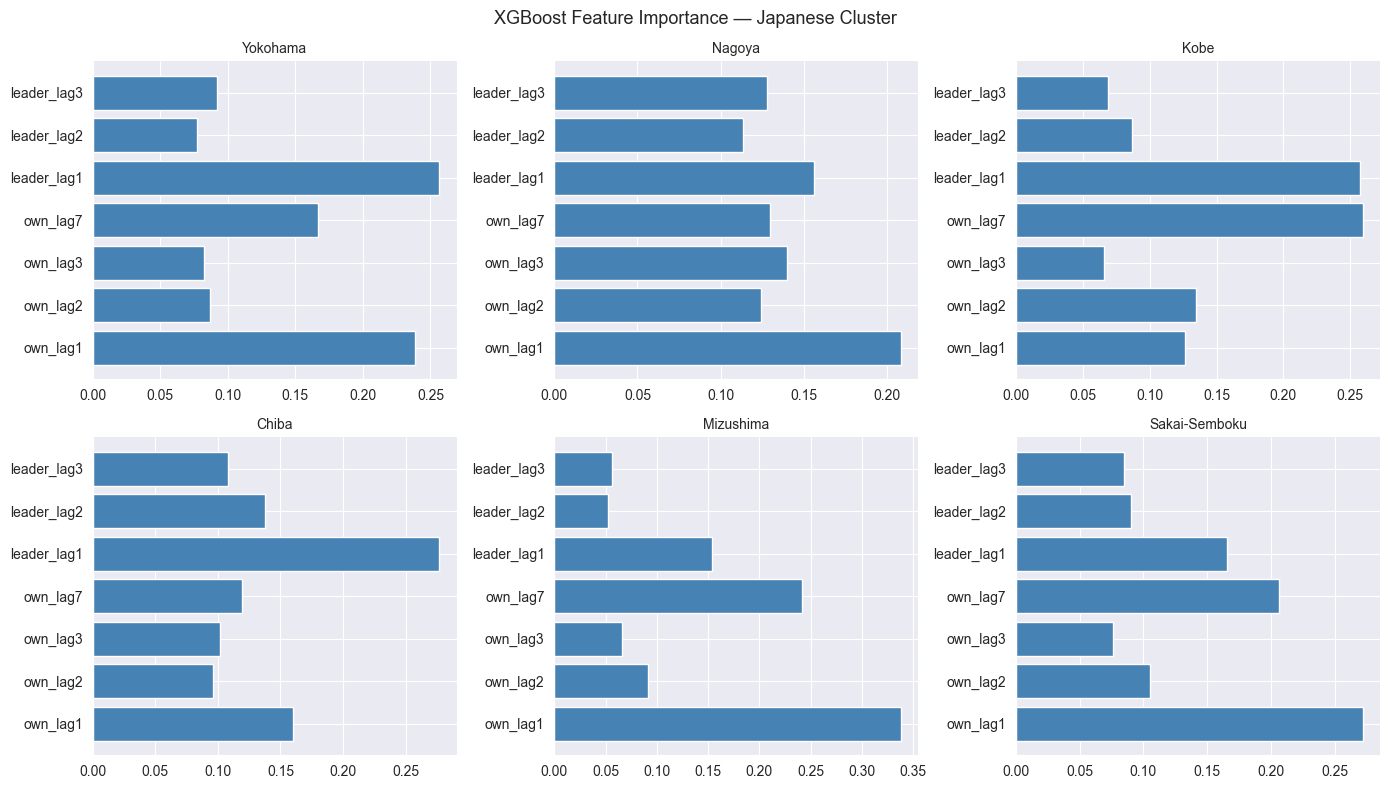

In [15]:
# Feature importance for Japanese cluster ports
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("XGBoost Feature Importance — Japanese Cluster", fontsize=13)
axes = axes.flatten()

for ax, port in zip(axes, clusters['Japanese Cluster']):
    model = xgb_models[port]['model']
    feat_names = xgb_models[port]['model'].get_booster().feature_names
    importances = model.feature_importances_

    ax.barh(feat_names, importances, color='steelblue')
    ax.set_title(port, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/figures/12_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Final Comparison — All Models

We now compare all models against the Phase 2 ARIMA baseline.
The question: did advanced models justify their complexity?

In [16]:
# Build final comparison table
final_comparison = arima_df[['port', 'MAPE']].copy()
final_comparison.columns = ['port', 'ARIMA_MAPE']

# Add Holt-Winters
hw_df = pd.read_csv('../outputs/processed/hw_results.csv')
final_comparison = final_comparison.merge(
    hw_df[['port','MAPE']].rename(columns={'MAPE':'HW_MAPE'}), on='port')

# Add Prophet
final_comparison = final_comparison.merge(
    prophet_df[['port','Prophet_MAPE']], on='port')

# Add XGBoost
final_comparison = final_comparison.merge(
    xgb_df[['port','XGB_MAPE']], on='port')

# Best model per port
final_comparison['Best'] = final_comparison[
    ['ARIMA_MAPE','HW_MAPE','Prophet_MAPE','XGB_MAPE']
].idxmin(axis=1).str.replace('_MAPE','')

print("Final Model Comparison — All Ports:\n")
print(final_comparison.to_string(index=False))
print(f"\nModel wins:")
print(final_comparison['Best'].value_counts().to_string())

Final Model Comparison — All Ports:

                 port  ARIMA_MAPE  HW_MAPE  Prophet_MAPE  XGB_MAPE    Best
              Antwerp       17.35    17.13         17.57     19.25      HW
                Busan       13.12    12.44         12.37     14.40 Prophet
                Chiba       29.85    26.78         26.24     26.72 Prophet
   Guangzhou (Nansha)       17.38    18.16         20.22     17.44   ARIMA
Gwangyang (Kwangyang)       17.77    18.38         16.77     19.32 Prophet
            Hong Kong       13.01    12.74         12.15     12.36 Prophet
            Kaohsiung       26.47    25.90         26.19     28.77      HW
                 Kobe       27.31    27.43         27.12     21.78     XGB
            Mizushima       28.25    28.75         28.43     22.77     XGB
               Nagoya       30.89    29.41         29.25     26.39     XGB
               Ningbo       15.15    15.27         15.80     15.49   ARIMA
           Port Klang       13.60    15.12         14.08     15

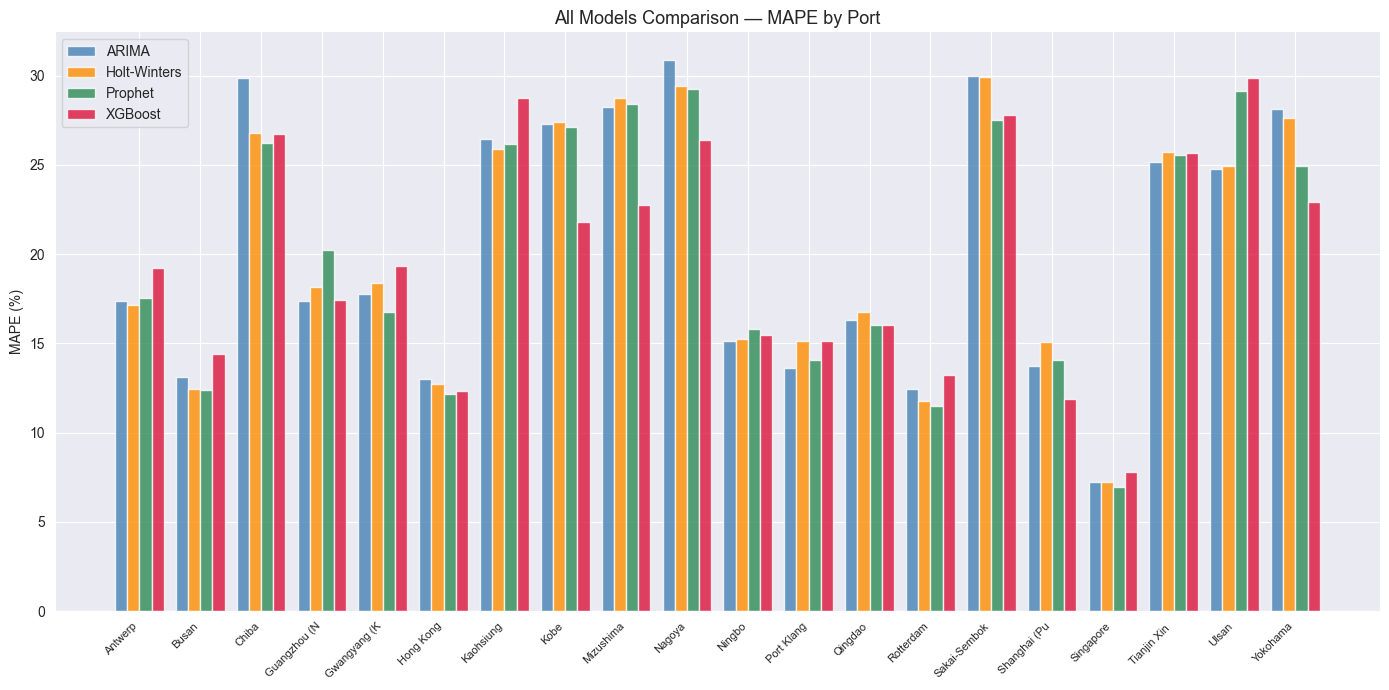

In [17]:
# Visualise final comparison
fig, ax = plt.subplots(figsize=(14, 7))

x     = np.arange(len(top_ports))
width = 0.2

ax.bar(x - 1.5*width, final_comparison['ARIMA_MAPE'],
       width, label='ARIMA', color='steelblue', alpha=0.8)
ax.bar(x - 0.5*width, final_comparison['HW_MAPE'],
       width, label='Holt-Winters', color='darkorange', alpha=0.8)
ax.bar(x + 0.5*width, final_comparison['Prophet_MAPE'],
       width, label='Prophet', color='seagreen', alpha=0.8)
ax.bar(x + 1.5*width, final_comparison['XGB_MAPE'],
       width, label='XGBoost', color='crimson', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels([p[:12] for p in top_ports],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel("MAPE (%)")
ax.set_title("All Models Comparison — MAPE by Port", fontsize=13)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../outputs/figures/13_final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Save Phase 3 results
var_df.to_csv('../outputs/processed/var_results.csv', index=False)
prophet_df.to_csv('../outputs/processed/prophet_results.csv', index=False)
xgb_df.to_csv('../outputs/processed/xgb_results.csv', index=False)
final_comparison.to_csv('../outputs/processed/final_comparison.csv', index=False)

print("Saved:")
print("  var_results.csv")
print("  prophet_results.csv")
print("  xgb_results.csv")
print("  final_co"
      "mparison.csv")

Saved:
  var_results.csv
  prophet_results.csv
  xgb_results.csv
  final_comparison.csv
